In [3]:
!pip install lightgbm optuna


In [4]:
import pandas as pd

train = pd.read_csv("/content/train (1).csv")
test = pd.read_csv("/content/test (1).csv")

train.head()

,id,age,income,loan_amount,credit_score,city,employment_type,target
0,1,56,25903,33815,719,D,salaried,1
1,2,69,53051,16802,551,D,student,0
2,3,46,38654,21797,848,D,salaried,0
3,4,32,28666,27460,634,B,student,1
4,5,60,40301,8653,391,C,student,0


In [5]:
TARGET = "target"
ID_COL = "id"

y = train[TARGET]
X = train.drop([TARGET, ID_COL], axis=1)

test_ids = test[ID_COL]
test = test.drop([ID_COL], axis=1)


In [6]:
cat_cols = X.select_dtypes(include=['object']).columns

for col in cat_cols:
    X[col] = X[col].astype('category')
    test[col] = test[col].astype('category')


In [7]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))


In [8]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.03,
    "num_leaves": 64,
    "n_estimators": 1500,
    "max_depth": -1,
    "random_state": 42
}

fold_scores = []
oof_preds = np.zeros(len(X))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = lgb.LGBMClassifier(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(100)]
    )

    preds = model.predict_proba(X_valid)[:,1]

    fold_auc = roc_auc_score(y_valid, preds)
    fold_scores.append(fold_auc)

    oof_preds[valid_idx] = preds

    print(f"Fold {fold} AUC:", fold_auc)

print("Mean of fold AUCs:", np.mean(fold_scores))
print("OOF AUC:", roc_auc_score(y, oof_preds))

[LightGBM] [Info] Number of positive: 154, number of negative: 646
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 815
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.192500 -> initscore=-1.433847
[LightGBM] [Info] Start training from score -1.433847
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [9]:
import time

start = time.time()
_ = model.predict_proba(test)
print("Inference time:", time.time() - start)


Inference time: 0.020985841751098633


In [10]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET: test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()


,id,target
0,1,0.0
1,2,0.0
2,3,0.0
3,4,0.0
4,5,0.0


In [11]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

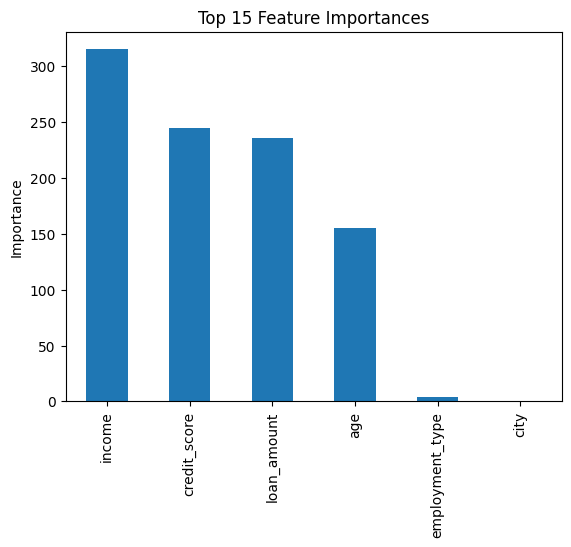

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure()
importances.head(15).plot(kind="bar")
plt.title("Top 15 Feature Importances")
plt.ylabel("Importance")
plt.show()


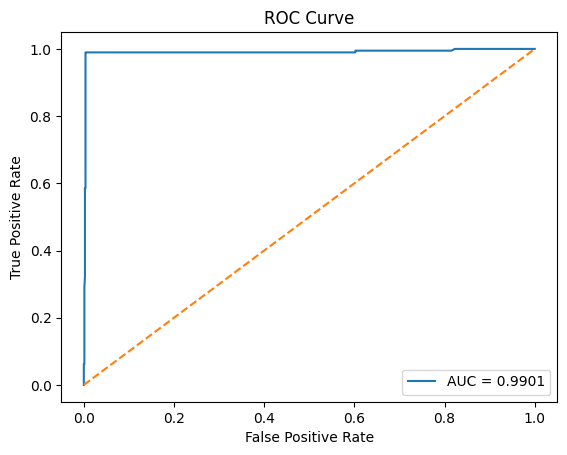

In [13]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y, oof_preds)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


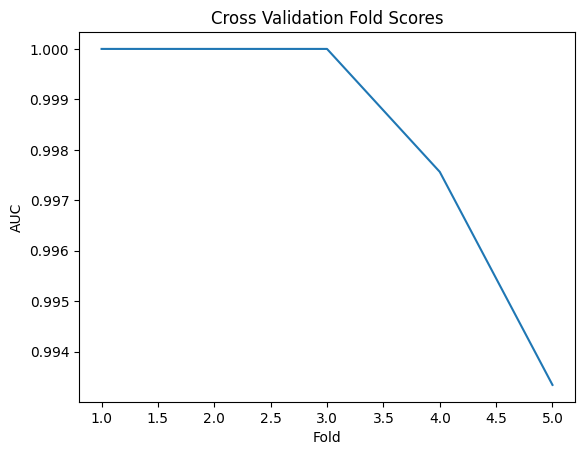

In [14]:
plt.figure()
plt.plot(range(1, 6), fold_scores)
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.title("Cross Validation Fold Scores")
plt.show()


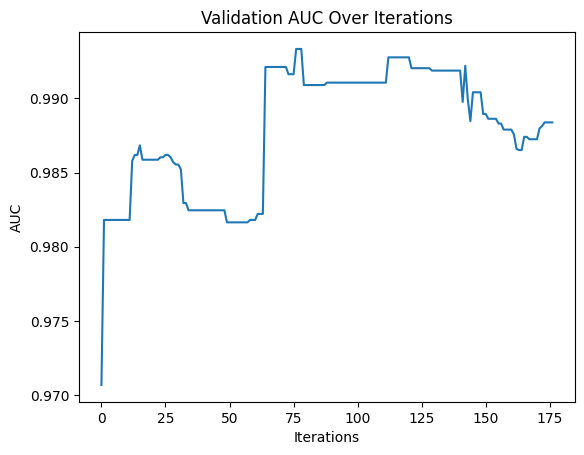

In [15]:
evals_result = model.evals_result_

plt.figure()
plt.plot(evals_result['valid_0']['auc'])
plt.xlabel("Iterations")
plt.ylabel("AUC")
plt.title("Validation AUC Over Iterations")
plt.show()
